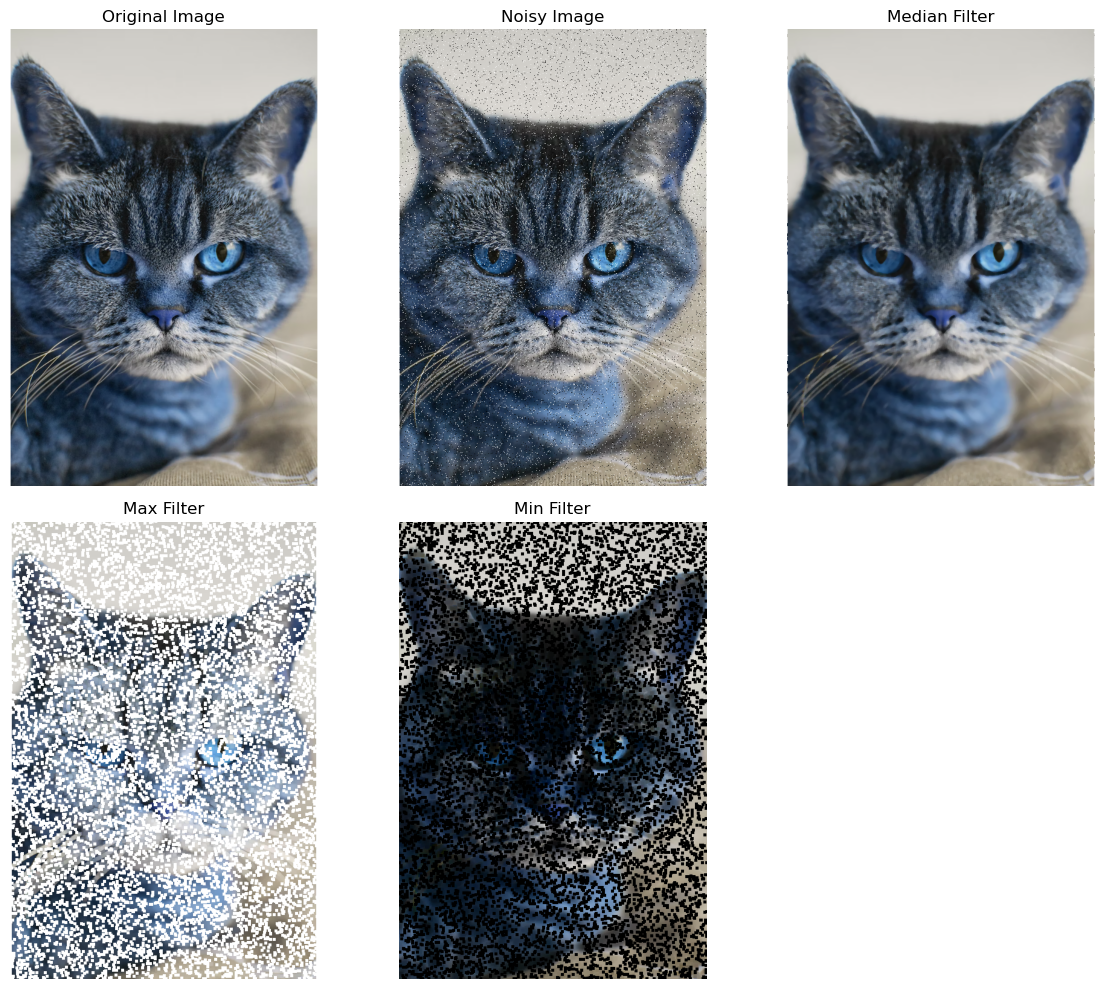

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read Image
image = cv2.imread("cat.png")

# Add Salt-and-Pepper Noise

noisy_image = image.copy()

# Amount of noise
noise_probability = 0.05

# Random noise mask
random_values = np.random.random(image.shape[:2])

# Salt noise (white)
noisy_image[random_values < noise_probability / 2] = 255

# Pepper noise (black)
noisy_image[
    (random_values >= noise_probability / 2) &
    (random_values < noise_probability)
] = 0

# 1. Median Filter

# Median filter is very effective for
# salt-and-pepper noise
median_filter = cv2.medianBlur(noisy_image, 5)

# 2. Max Filter

# Max filter replaces each pixel with
# the maximum value in its neighborhood

kernel = np.ones((5, 5), np.uint8)

max_filter = cv2.dilate(noisy_image, kernel)

# 3. Min Filter

# Min filter replaces each pixel with
# the minimum value in its neighborhood

min_filter = cv2.erode(noisy_image, kernel)

# Display Results
plt.figure(figsize=(12, 10))

# Original
plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

# Noisy
plt.subplot(2, 3, 2)
plt.imshow(noisy_image)
plt.title("Noisy Image")
plt.axis("off")

# Median
plt.subplot(2, 3, 3)
plt.imshow(median_filter)
plt.title("Median Filter")
plt.axis("off")

# Max
plt.subplot(2, 3, 4)
plt.imshow(max_filter)
plt.title("Max Filter")
plt.axis("off")

# Min
plt.subplot(2, 3, 5)
plt.imshow(min_filter)
plt.title("Min Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

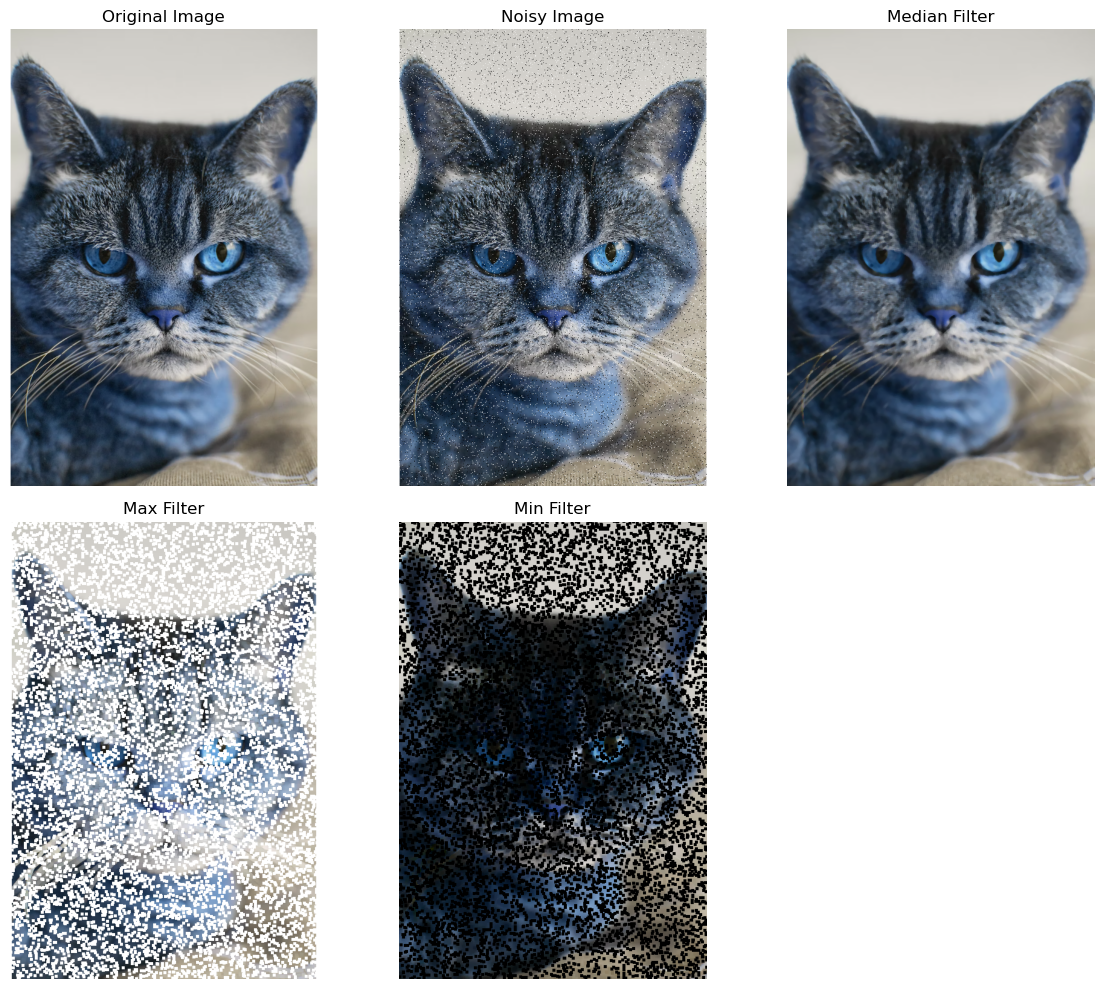

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read Image
image = cv2.imread("cat.png")

# Add Salt-and-Pepper Noise
noisy_image = image.copy()

# Amount of noise
noise_probability = 0.05

# Random noise mask
random_values = np.random.random(image.shape[:2])

# Salt noise (white)
noisy_image[random_values < noise_probability / 2] = 255

# Pepper noise (black)
noisy_image[
    (random_values >= noise_probability / 2) &
    (random_values < noise_probability)
] = 0

# Manual Filter Implementations
def median_filter_manual(image, kernel_size=5):
    """Apply median filter manually"""
    h, w = image.shape[:2]
    pad = kernel_size // 2
    output = np.zeros_like(image, dtype=np.float32)
    
    # Add padding to the image
    if len(image.shape) == 3:
        padded = np.pad(image, ((pad, pad), (pad, pad), (0, 0)), mode='reflect')
    else:
        padded = np.pad(image, pad, mode='reflect')
    
    # Apply filter
    for i in range(h):
        for j in range(w):
            if len(image.shape) == 3:
                for c in range(image.shape[2]):
                    region = padded[i:i+kernel_size, j:j+kernel_size, c]
                    output[i, j, c] = np.median(region)
            else:
                region = padded[i:i+kernel_size, j:j+kernel_size]
                output[i, j] = np.median(region)
    
    return np.uint8(output)

def max_filter_manual(image, kernel_size=5):
    """Apply max filter manually (dilate operation)"""
    h, w = image.shape[:2]
    pad = kernel_size // 2
    output = np.zeros_like(image, dtype=np.float32)
    
    # Add padding to the image
    if len(image.shape) == 3:
        padded = np.pad(image, ((pad, pad), (pad, pad), (0, 0)), mode='reflect')
    else:
        padded = np.pad(image, pad, mode='reflect')
    
    # Apply filter
    for i in range(h):
        for j in range(w):
            if len(image.shape) == 3:
                for c in range(image.shape[2]):
                    region = padded[i:i+kernel_size, j:j+kernel_size, c]
                    output[i, j, c] = np.max(region)
            else:
                region = padded[i:i+kernel_size, j:j+kernel_size]
                output[i, j] = np.max(region)
    
    return np.uint8(output)

def min_filter_manual(image, kernel_size=5):
    """Apply min filter manually (erode operation)"""
    h, w = image.shape[:2]
    pad = kernel_size // 2
    output = np.zeros_like(image, dtype=np.float32)
    
    # Add padding to the image
    if len(image.shape) == 3:
        padded = np.pad(image, ((pad, pad), (pad, pad), (0, 0)), mode='reflect')
    else:
        padded = np.pad(image, pad, mode='reflect')
    
    # Apply filter
    for i in range(h):
        for j in range(w):
            if len(image.shape) == 3:
                for c in range(image.shape[2]):
                    region = padded[i:i+kernel_size, j:j+kernel_size, c]
                    output[i, j, c] = np.min(region)
            else:
                region = padded[i:i+kernel_size, j:j+kernel_size]
                output[i, j] = np.min(region)
    
    return np.uint8(output)

# 1. Median Filter
# Median filter is very effective for
# salt-and-pepper noise
median_filter = median_filter_manual(noisy_image, 5)

# 2. Max Filter
# Max filter replaces each pixel with
# the maximum value in its neighborhood
max_filter = max_filter_manual(noisy_image, 5)

# 3. Min Filter
# Min filter replaces each pixel with
# the minimum value in its neighborhood
min_filter = min_filter_manual(noisy_image, 5)

# Display Results
plt.figure(figsize=(12, 10))

# Original
plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

# Noisy
plt.subplot(2, 3, 2)
plt.imshow(noisy_image)
plt.title("Noisy Image")
plt.axis("off")

# Median
plt.subplot(2, 3, 3)
plt.imshow(median_filter)
plt.title("Median Filter")
plt.axis("off")

# Max
plt.subplot(2, 3, 4)
plt.imshow(max_filter)
plt.title("Max Filter")
plt.axis("off")

# Min
plt.subplot(2, 3, 5)
plt.imshow(min_filter)
plt.title("Min Filter")
plt.axis("off")

plt.tight_layout()
plt.show()